### Compute the football field

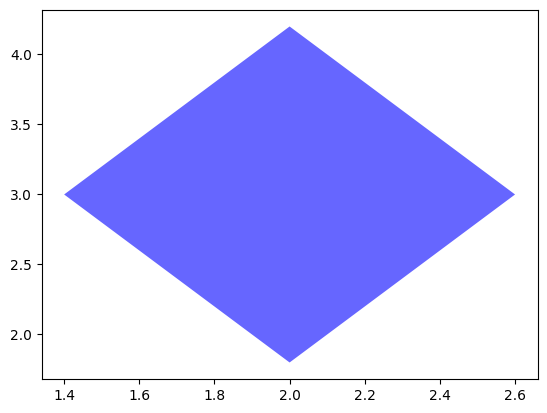

In [3]:
import matplotlib.pyplot as plt

def plot_filled_rhombus(a, b,p):
    # Coordenadas de los vértices
    vertices = [
        (a, b + 1.20*p),  # Arriba
        (a + 0.6*p, b),  # Derecha
        (a, b - 1.20*p),  # Abajo
        (a - 0.6*p, b)   # Izquierda
    ]

    x, y = zip(*vertices)  # Extraer coordenadas x e y

    plt.fill(x, y, 'b', alpha=0.6)  # Dibujar y rellenar el rombo con color azul y transparencia

# Ejemplo con a = 2, b = 3
plot_filled_rhombus(2, 3,1)


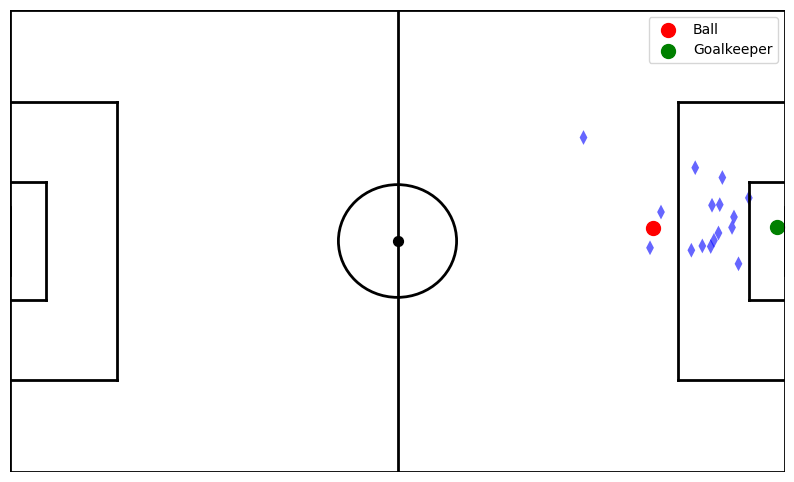

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def dibujar_campo_futbol(pos_balon,portero, jugadores):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Dibujar el campo
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 75)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    
    # Dibujar los límites del campo
    ax.plot([0, 120, 120, 0, 0], [0, 0, 75, 75, 0], color="black", linewidth=2)
    
    # Dibujar las porterías
    porteria_izq = [(0, 32), (0, 43)]
    porteria_der = [(120, 32), (120, 43)]
    ax.plot([0, 0], [32, 43], color="black", linewidth=2)
    ax.plot([120, 120], [32, 43], color="black", linewidth=2)
    
    # Dibujar el área de penalti
    ax.plot([0, 16.5], [15, 15], color="black", linewidth=2)
    ax.plot([0, 16.5], [60, 60], color="black", linewidth=2)
    ax.plot([16.5, 16.5], [15, 60], color="black", linewidth=2)
    
    ax.plot([120, 103.5], [15, 15], color="black", linewidth=2)
    ax.plot([120, 103.5], [60, 60], color="black", linewidth=2)
    ax.plot([103.5, 103.5], [15, 60], color="black", linewidth=2)
    
    # Dibujar el área pequeña
    ax.plot([0, 5.5], [28, 28], color="black", linewidth=2)
    ax.plot([0, 5.5], [47, 47], color="black", linewidth=2)
    ax.plot([5.5, 5.5], [28, 47], color="black", linewidth=2)
    
    ax.plot([120, 114.5], [28, 28], color="black", linewidth=2)
    ax.plot([120, 114.5], [47, 47], color="black", linewidth=2)
    ax.plot([114.5, 114.5], [28, 47], color="black", linewidth=2)
    
    # Dibujar el círculo central
    circulo_central = plt.Circle((60, 37.5), 9.15, color='black', fill=False, linewidth=2)
    ax.add_patch(circulo_central)
    ax.scatter(60, 37.5, color='black', s=50)  # Punto central
    
    # Dibujar la línea central
    ax.plot([60, 60], [0, 75], color="black", linewidth=2)
    
    # Dibujar el balón
    ax.scatter(*pos_balon, color='red', s=100, label="Ball")
    
    
    # Dibujar jugadores
    for jugador in jugadores:
        plot_filled_rhombus(jugador[0], jugador[1],1)
    ax.scatter(*portero, color='green', s=100, label = "Goalkeeper")

    plt.legend()
    plt.show()

# Ejemplo de uso

dibujar_campo_futbol([99.5, 39.6],[118.7, 39.7] ,[[105.5, 36.0], [110.3, 47.8], [108.7, 43.3], [109.7, 38.8], [109.0, 37.6], [109.9, 43.4], [112.8, 33.8], [108.5, 36.6], [107.2, 36.7], [112.1, 41.4], [114.4, 44.5], [106.1, 49.4], [111.8, 39.7], [99.1, 36.4], [100.8, 42.2], [88.8, 54.3]])

### Calculate the influence of the players in the shot with pixel count

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.path import Path
from PIL import Image

def xss(pos_balon, portero, jugadores):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 75)
    ax.set_xticks([])  
    ax.set_yticks([])  
    ax.set_frame_on(False)

    # Fondo blanco puro
    ax.set_facecolor('white')

    # Dibujar portería
    porteria = [(120, 32), (120, 43)] if pos_balon[0] >= 60 else [(0, 32), (0, 43)]

    # Vértices del triángulo
    vertices_triangulo = np.array([pos_balon, porteria[0], porteria[1]])

    # Dibujar triángulo rojo puro sin transparencia
    triangulo = Polygon(vertices_triangulo, closed=True, edgecolor='red', facecolor=(1, 0, 0), linewidth=2)
    ax.add_patch(triangulo)

    # Dibujar balón
    ax.scatter(*pos_balon, color='red', s=100, label="Ball")

    # Dibujar jugadores
    for jugador in jugadores:
        plot_filled_rhombus(jugador[0], jugador[1],1)

    # Dibujar portero
    por = plt.Circle(portero, radius=3, color='green', label="Goalkeeper")
    ax.add_patch(por)

    plt.legend()

    # Renderizar imagen
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape((h, w, 3))
    plt.close(fig)

    # Transformar vértices del triángulo a coordenadas de imagen (pixeles)
    transform = ax.transData
    pix_vertices = transform.transform(vertices_triangulo)

    # Invertir las coordenadas Y para corregir el efecto espejo
    pix_vertices[:, 1] = h - pix_vertices[:, 1]

    # Crear máscara de pixeles dentro del triángulo
    path = Path(pix_vertices)
    Y, X = np.mgrid[0:h, 0:w]
    coords = np.vstack((X.ravel(), Y.ravel())).T
    mask = path.contains_points(coords).reshape((h, w))

    # Extraer colores dentro del triángulo
    colores_dentro = image[mask]

    # Agrupar colores por redondeo
    colores_redondeados = (colores_dentro // 10) * 10
    colores_unicos, counts = np.unique(colores_redondeados, axis=0, return_counts=True)

    print(f"\n Píxeles dentro del triángulo (sin contar blancos): {np.sum(counts)}")
    print("Colores dentro del triángulo (agrupados):")
    for color, count in zip(colores_unicos, counts):
        porcentaje = 100 * count / np.sum(counts)
        print(f"  RGB {tuple(color)}: {count} píxeles ({porcentaje:.2f}%)")

# Ejemplo de uso
xss(
    [99.5, 39.6], [118.7, 39.7],
    [[105.5, 36.0], [110.3, 47.8], [108.7, 43.3], [109.7, 38.8], [109.0, 37.6], [109.9, 43.4],
     [112.8, 33.8], [108.5, 36.6], [107.2, 36.7], [112.1, 41.4], [114.4, 44.5], [106.1, 49.4],
     [111.8, 39.7], [99.1, 36.4], [100.8, 42.2], [88.8, 54.3]]
)



 Píxeles dentro del triángulo (sin contar blancos): 4452
Colores dentro del triángulo (agrupados):
  RGB (np.uint8(0), np.uint8(120), np.uint8(0)): 877 píxeles (19.70%)
  RGB (np.uint8(10), np.uint8(110), np.uint8(0)): 4 píxeles (0.09%)
  RGB (np.uint8(10), np.uint8(120), np.uint8(0)): 3 píxeles (0.07%)
  RGB (np.uint8(20), np.uint8(110), np.uint8(0)): 2 píxeles (0.04%)
  RGB (np.uint8(40), np.uint8(0), np.uint8(200)): 1 píxeles (0.02%)
  RGB (np.uint8(40), np.uint8(0), np.uint8(210)): 2 píxeles (0.04%)
  RGB (np.uint8(40), np.uint8(100), np.uint8(0)): 2 píxeles (0.04%)
  RGB (np.uint8(50), np.uint8(0), np.uint8(190)): 3 píxeles (0.07%)
  RGB (np.uint8(50), np.uint8(0), np.uint8(200)): 1 píxeles (0.02%)
  RGB (np.uint8(50), np.uint8(90), np.uint8(0)): 1 píxeles (0.02%)
  RGB (np.uint8(50), np.uint8(100), np.uint8(0)): 1 píxeles (0.02%)
  RGB (np.uint8(60), np.uint8(0), np.uint8(180)): 1 píxeles (0.02%)
  RGB (np.uint8(60), np.uint8(90), np.uint8(0)): 3 píxeles (0.07%)
  RGB (np.uint8(

C:\Users\Usuario\AppData\Local\Temp\ipykernel_10536\2144930554.py:45: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape((h, w, 3))


### Calculate XSS value without speed

C:\Users\Usuario\AppData\Local\Temp\ipykernel_10536\3785528234.py:47: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape((h, w, 3))


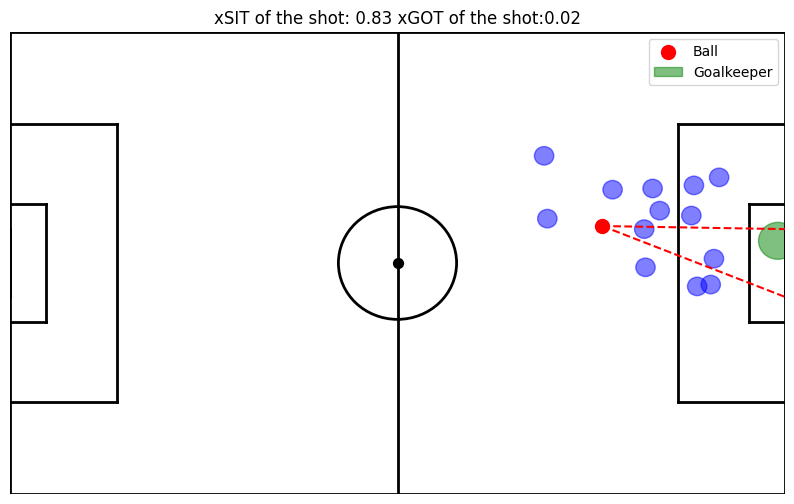

In [54]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon, Circle
from matplotlib.path import Path
from PIL import Image
import ast

def xsit_value(pos_balon, portero, jugadores):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 75)
    ax.set_xticks([])  
    ax.set_yticks([])  
    ax.set_frame_on(False)

    # Fondo blanco puro
    ax.set_facecolor('white')

    # Dibujar portería
    porteria = [(120, 32), (120, 43)] if pos_balon[0] >= 60 else [(0, 32), (0, 43)]

    # Vértices del triángulo
    vertices_triangulo = np.array([pos_balon, porteria[0], porteria[1]])

    # Dibujar triángulo rojo puro sin transparencia
    triangulo = Polygon(vertices_triangulo, closed=True, edgecolor='red', facecolor=(1, 0, 0), linewidth=2)
    ax.add_patch(triangulo)

    # Dibujar balón
    ax.scatter(*pos_balon, color='red', s=100, label="Ball")

    # Dibujar jugadores
    for jugador in jugadores:
        circulo = plt.Circle(jugador, radius=1.5, color='blue', alpha=0.5)
        ax.add_patch(circulo)

    # Dibujar portero
    por = plt.Circle(portero, radius=2, color='green', alpha=0.5, label="Goalkeeper")
    ax.add_patch(por)

    plt.legend()

    # Renderizar imagen
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape((h, w, 3))
    plt.close(fig)

    # Transformar vértices del triángulo a coordenadas de imagen (pixeles)
    transform = ax.transData
    pix_vertices = transform.transform(vertices_triangulo)

    # Invertir las coordenadas Y para corregir el efecto espejo
    pix_vertices[:, 1] = h - pix_vertices[:, 1]

    # Crear máscara de pixeles dentro del triángulo
    path = Path(pix_vertices)
    Y, X = np.mgrid[0:h, 0:w]
    coords = np.vstack((X.ravel(), Y.ravel())).T
    mask = path.contains_points(coords).reshape((h, w))

    # Extraer colores dentro del triángulo
    colores_dentro = image[mask]

    # Agrupar colores por redondeo
    colores_redondeados = (colores_dentro // 10) * 10
    colores_unicos, counts = np.unique(colores_redondeados, axis=0, return_counts=True)

    for color, count in zip(colores_unicos, counts):
        if tuple(color) == (250, 0, 0):
            porcentaje = count / np.sum(counts)
            return porcentaje


def dibujar_campo_futbol(pos_balon,portero, jugadores):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Dibujar el campo
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 75)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    
    # Dibujar los límites del campo
    ax.plot([0, 120, 120, 0, 0], [0, 0, 75, 75, 0], color="black", linewidth=2)
    
    # Dibujar las porterías
    porteria_izq = [(0, 32), (0, 43)]
    porteria_der = [(120, 32), (120, 43)]
    ax.plot([0, 0], [32, 43], color="black", linewidth=2)
    ax.plot([120, 120], [32, 43], color="black", linewidth=2)
    
    # Dibujar el área de penalti
    ax.plot([0, 16.5], [15, 15], color="black", linewidth=2)
    ax.plot([0, 16.5], [60, 60], color="black", linewidth=2)
    ax.plot([16.5, 16.5], [15, 60], color="black", linewidth=2)
    
    ax.plot([120, 103.5], [15, 15], color="black", linewidth=2)
    ax.plot([120, 103.5], [60, 60], color="black", linewidth=2)
    ax.plot([103.5, 103.5], [15, 60], color="black", linewidth=2)
    
    # Dibujar el área pequeña
    ax.plot([0, 5.5], [28, 28], color="black", linewidth=2)
    ax.plot([0, 5.5], [47, 47], color="black", linewidth=2)
    ax.plot([5.5, 5.5], [28, 47], color="black", linewidth=2)
    
    ax.plot([120, 114.5], [28, 28], color="black", linewidth=2)
    ax.plot([120, 114.5], [47, 47], color="black", linewidth=2)
    ax.plot([114.5, 114.5], [28, 47], color="black", linewidth=2)
    
    # Dibujar el círculo central
    circulo_central = plt.Circle((60, 37.5), 9.15, color='black', fill=False, linewidth=2)
    ax.add_patch(circulo_central)
    ax.scatter(60, 37.5, color='black', s=50)  # Punto central
    
    # Dibujar la línea central
    ax.plot([60, 60], [0, 75], color="black", linewidth=2)
    
    # Dibujar el balón
    ax.scatter(*pos_balon, color='red', s=100, label="Ball")
    
    # Dibujar líneas desde el balón a las esquinas de la portería más cercana
    if pos_balon[0] < 60:  # Balón en el lado izquierdo
        porteria = porteria_izq
    else:  # Balón en el lado derecho
        porteria = porteria_der
    
    for esquina in porteria:
        ax.plot([pos_balon[0], esquina[0]], [pos_balon[1], esquina[1]], color='red', linestyle='dashed')
    
    # Dibujar jugadores
    for jugador in jugadores:
        circulo = Circle(jugador, radius=1.5, color='blue', alpha=0.5)
        ax.add_patch(circulo)
    por = plt.Circle(portero, radius=3, color='green', alpha=0.5, label = "Goalkeeper")
    ax.add_patch(por)
    porcentaje = xsit_value(pos_balon,portero, jugadores)
    plt.title(f"xSIT of the shot: {porcentaje:.2f} xGOT of the shot:{0.02:.2f}")
    plt.legend()
    plt.show()

# Ejemplo de uso
pos_balon = "[91.7, 43.5]"
pos_balon = ast.literal_eval(pos_balon)
portero = "[118.9, 41.1]"
portero = ast.literal_eval(portero)
jugadores = "[[109.8, 51.4], [98.4, 36.8], [83.2, 44.7], [109.0, 38.2], [108.5, 34.0], [105.5, 45.2], [105.9, 50.1], [98.2, 43.0], [99.5, 49.6], [106.4, 33.7], [100.6, 46.0], [93.3, 49.4], [82.7, 54.9]]"
jugadores = ast.literal_eval(jugadores)
dibujar_campo_futbol(pos_balon,portero,jugadores)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_10536\4293414279.py:45: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape((h, w, 3))


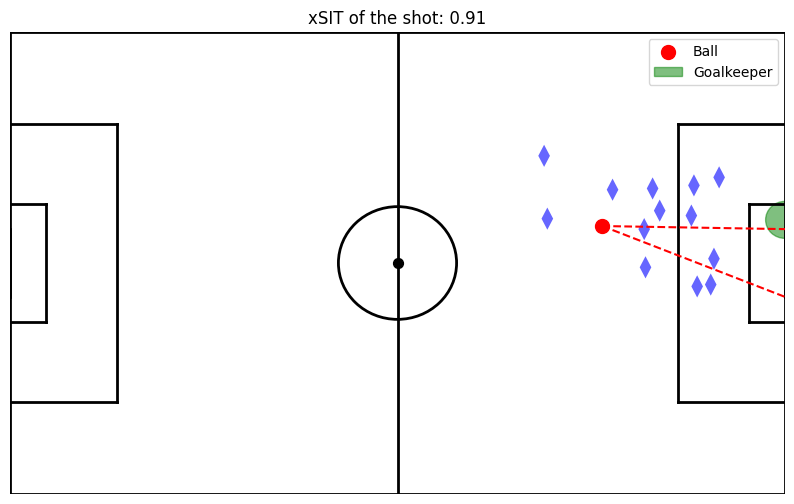

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.path import Path
from PIL import Image

def xss_value(pos_balon, portero, jugadores):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 75)
    ax.set_xticks([])  
    ax.set_yticks([])  
    ax.set_frame_on(False)

    # Fondo blanco puro
    ax.set_facecolor('white')

    # Dibujar portería
    porteria = [(120, 32), (120, 43)] if pos_balon[0] >= 60 else [(0, 32), (0, 43)]

    # Vértices del triángulo
    vertices_triangulo = np.array([pos_balon, porteria[0], porteria[1]])

    # Dibujar triángulo rojo puro sin transparencia
    triangulo = Polygon(vertices_triangulo, closed=True, edgecolor='red', facecolor=(1, 0, 0), linewidth=2)
    ax.add_patch(triangulo)

    # Dibujar balón
    ax.scatter(*pos_balon, color='red', s=100, label="Ball")

    # Dibujar jugadores
    for jugador in jugadores:
        plot_filled_rhombus(jugador[0], jugador[1],2)

    # Dibujar portero
    por = plt.Circle(portero, radius=3, color='green', label="Goalkeeper")
    ax.add_patch(por)

    plt.legend()

    # Renderizar imagen
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape((h, w, 3))
    plt.close(fig)

    # Transformar vértices del triángulo a coordenadas de imagen (pixeles)
    transform = ax.transData
    pix_vertices = transform.transform(vertices_triangulo)

    # Invertir las coordenadas Y para corregir el efecto espejo
    pix_vertices[:, 1] = h - pix_vertices[:, 1]

    # Crear máscara de pixeles dentro del triángulo
    path = Path(pix_vertices)
    Y, X = np.mgrid[0:h, 0:w]
    coords = np.vstack((X.ravel(), Y.ravel())).T
    mask = path.contains_points(coords).reshape((h, w))

    # Extraer colores dentro del triángulo
    colores_dentro = image[mask]

    # Agrupar colores por redondeo
    colores_redondeados = (colores_dentro // 10) * 10
    colores_unicos, counts = np.unique(colores_redondeados, axis=0, return_counts=True)

    for color, count in zip(colores_unicos, counts):
        if tuple(color) == (np.uint8(250), np.uint8(0), np.uint8(0)):
            porcentaje = 100 * count / np.sum(counts)
            return porcentaje


def dibujar_campo_futbol(pos_balon,portero, jugadores):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Dibujar el campo
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 75)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    
    # Dibujar los límites del campo
    ax.plot([0, 120, 120, 0, 0], [0, 0, 75, 75, 0], color="black", linewidth=2)
    
    # Dibujar las porterías
    porteria_izq = [(0, 32), (0, 43)]
    porteria_der = [(120, 32), (120, 43)]
    ax.plot([0, 0], [32, 43], color="black", linewidth=2)
    ax.plot([120, 120], [32, 43], color="black", linewidth=2)
    
    # Dibujar el área de penalti
    ax.plot([0, 16.5], [15, 15], color="black", linewidth=2)
    ax.plot([0, 16.5], [60, 60], color="black", linewidth=2)
    ax.plot([16.5, 16.5], [15, 60], color="black", linewidth=2)
    
    ax.plot([120, 103.5], [15, 15], color="black", linewidth=2)
    ax.plot([120, 103.5], [60, 60], color="black", linewidth=2)
    ax.plot([103.5, 103.5], [15, 60], color="black", linewidth=2)
    
    # Dibujar el área pequeña
    ax.plot([0, 5.5], [28, 28], color="black", linewidth=2)
    ax.plot([0, 5.5], [47, 47], color="black", linewidth=2)
    ax.plot([5.5, 5.5], [28, 47], color="black", linewidth=2)
    
    ax.plot([120, 114.5], [28, 28], color="black", linewidth=2)
    ax.plot([120, 114.5], [47, 47], color="black", linewidth=2)
    ax.plot([114.5, 114.5], [28, 47], color="black", linewidth=2)
    
    # Dibujar el círculo central
    circulo_central = plt.Circle((60, 37.5), 9.15, color='black', fill=False, linewidth=2)
    ax.add_patch(circulo_central)
    ax.scatter(60, 37.5, color='black', s=50)  # Punto central
    
    # Dibujar la línea central
    ax.plot([60, 60], [0, 75], color="black", linewidth=2)
    
    # Dibujar el balón
    ax.scatter(*pos_balon, color='red', s=100, label="Ball")
    
    # Dibujar líneas desde el balón a las esquinas de la portería más cercana
    if pos_balon[0] < 60:  # Balón en el lado izquierdo
        porteria = porteria_izq
    else:  # Balón en el lado derecho
        porteria = porteria_der
    
    for esquina in porteria:
        ax.plot([pos_balon[0], esquina[0]], [pos_balon[1], esquina[1]], color='red', linestyle='dashed')
    
    # Dibujar jugadores
    for jugador in jugadores:
        plot_filled_rhombus(jugador[0], jugador[1],1.5)
    por = plt.Circle(portero, radius=3, color='green', alpha=0.5, label = "Goalkeeper")
    ax.add_patch(por)
    porcentaje = xss_value(pos_balon,portero, jugadores)/100
    plt.title(f"xSIT of the shot: {porcentaje:.2f}")
    plt.legend()
    plt.show()

# Ejemplo de uso

dibujar_campo_futbol( pos_balon=[91.7, 43.5],
    portero=[120.0, 44.5, 5.3],
    jugadores=[[109.8, 51.4], [98.4, 36.8], [83.2, 44.7], [109.0, 38.2], [108.5, 34.0], [105.5, 45.2], [105.9, 50.1], [98.2, 43.0], [99.5, 49.6], [106.4, 33.7], [100.6, 46.0], [93.3, 49.4], [82.7, 54.9]])

C:\Users\Usuario\AppData\Local\Temp\ipykernel_10536\3593278074.py:56: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape((h, w, 3))


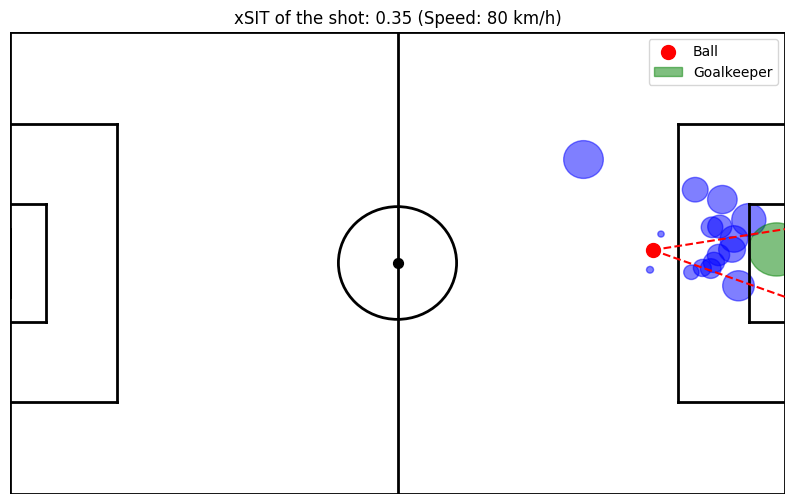

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon, Circle
from matplotlib.path import Path
import math

def calcular_tiempo_llegada(pos_balon, velocidad_balon, pos_jugador):
    """Calcula el tiempo que tarda el balón en llegar a la posición del jugador"""
    distancia = math.sqrt((pos_balon[0] - pos_jugador[0])**2 + (pos_balon[1] - pos_jugador[1])**2)
    tiempo = distancia / (velocidad_balon * 1000/3600)  # Convertir km/h a m/s
    return tiempo

def calcular_radio_efectivo(tiempo_llegada, radio_base=1.5, tiempo_reaccion=0.4):
    """Ajusta el radio en función del tiempo de llegada vs tiempo de reacción"""
    factor = tiempo_llegada / tiempo_reaccion
    return radio_base * factor

def xss_value(pos_balon, portero, jugadores, velocidad_balon):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 75)
    ax.set_xticks([])  
    ax.set_yticks([])  
    ax.set_frame_on(False)
    ax.set_facecolor('white')

    # Portería
    porteria = [(120, 32), (120, 43)] if pos_balon[0] >= 60 else [(0, 32), (0, 43)]
    
    # Triángulo
    vertices_triangulo = np.array([pos_balon, porteria[0], porteria[1]])
    triangulo = Polygon(vertices_triangulo, closed=True, edgecolor='red', facecolor=(1, 0, 0), linewidth=2)
    ax.add_patch(triangulo)

    # Balón
    ax.scatter(*pos_balon, color='red', s=100, label="Ball")

    # Jugadores con radios dinámicos
    for jugador in jugadores:
        tiempo = calcular_tiempo_llegada(pos_balon, velocidad_balon, jugador)
        radio = calcular_radio_efectivo(tiempo, radio_base=1.5)
        circulo = Circle(jugador, radius=radio, color='blue', alpha=0.5)
        ax.add_patch(circulo)

    # Portero con radio dinámico
    tiempo_portero = calcular_tiempo_llegada(pos_balon, velocidad_balon, portero)
    radio_portero = calcular_radio_efectivo(tiempo_portero, radio_base=2.0)
    por = Circle(portero, radius=radio_portero, color='green', alpha=0.5, label="Goalkeeper")
    ax.add_patch(por)

    plt.legend()

    # Procesamiento de la imagen para calcular el área blanca
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape((h, w, 3))
    plt.close(fig)

    transform = ax.transData
    pix_vertices = transform.transform(vertices_triangulo)
    pix_vertices[:, 1] = h - pix_vertices[:, 1]

    path = Path(pix_vertices)
    Y, X = np.mgrid[0:h, 0:w]
    coords = np.vstack((X.ravel(), Y.ravel())).T
    mask = path.contains_points(coords).reshape((h, w))

    colores_dentro = image[mask]
    colores_redondeados = (colores_dentro // 10) * 10
    colores_unicos, counts = np.unique(colores_redondeados, axis=0, return_counts=True)

    for color, count in zip(colores_unicos, counts):
        if tuple(color) == (250, 0, 0):
            porcentaje = count / np.sum(counts)
            return porcentaje

def dibujar_campo_futbol(pos_balon, portero, jugadores, velocidad_balon=80):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Dibujar el campo (igual que antes)
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 75)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    
    # Límites del campo
    ax.plot([0, 120, 120, 0, 0], [0, 0, 75, 75, 0], color="black", linewidth=2)
    
    # Porterías
    porteria_izq = [(0, 32), (0, 43)]
    porteria_der = [(120, 32), (120, 43)]
    ax.plot([0, 0], [32, 43], color="black", linewidth=2)
    ax.plot([120, 120], [32, 43], color="black", linewidth=2)
    
    # Áreas (igual que antes)
    # Dibujar las porterías
    porteria_izq = [(0, 32), (0, 43)]
    porteria_der = [(120, 32), (120, 43)]
    ax.plot([0, 0], [32, 43], color="black", linewidth=2)
    ax.plot([120, 120], [32, 43], color="black", linewidth=2)
    
    # Dibujar el área de penalti
    ax.plot([0, 16.5], [15, 15], color="black", linewidth=2)
    ax.plot([0, 16.5], [60, 60], color="black", linewidth=2)
    ax.plot([16.5, 16.5], [15, 60], color="black", linewidth=2)
    
    ax.plot([120, 103.5], [15, 15], color="black", linewidth=2)
    ax.plot([120, 103.5], [60, 60], color="black", linewidth=2)
    ax.plot([103.5, 103.5], [15, 60], color="black", linewidth=2)
    
    # Dibujar el área pequeña
    ax.plot([0, 5.5], [28, 28], color="black", linewidth=2)
    ax.plot([0, 5.5], [47, 47], color="black", linewidth=2)
    ax.plot([5.5, 5.5], [28, 47], color="black", linewidth=2)
    
    ax.plot([120, 114.5], [28, 28], color="black", linewidth=2)
    ax.plot([120, 114.5], [47, 47], color="black", linewidth=2)
    ax.plot([114.5, 114.5], [28, 47], color="black", linewidth=2)

    # Dibujar el círculo central
    circulo_central = plt.Circle((60, 37.5), 9.15, color='black', fill=False, linewidth=2)
    ax.add_patch(circulo_central)
    ax.scatter(60, 37.5, color='black', s=50)  # Punto central
    
    # Dibujar la línea central
    ax.plot([60, 60], [0, 75], color="black", linewidth=2)
    
    # Dibujar el balón
    ax.scatter(*pos_balon, color='red', s=100, label="Ball")
    
    # Determinar portería más cercana
    if pos_balon[0] < 60:
        porteria = porteria_izq
    else:
        porteria = porteria_der
    
    # Líneas al balón
    for esquina in porteria:
        ax.plot([pos_balon[0], esquina[0]], [pos_balon[1], esquina[1]], color='red', linestyle='dashed')
    
    # Jugadores con radios dinámicos
    for jugador in jugadores:
        tiempo = calcular_tiempo_llegada(pos_balon, velocidad_balon, jugador)
        radio = calcular_radio_efectivo(tiempo, radio_base=1.5)
        circulo = Circle(jugador, radius=radio, color='blue', alpha=0.5)
        ax.add_patch(circulo)
    
    # Portero con radio dinámico
    tiempo_portero = calcular_tiempo_llegada(pos_balon, velocidad_balon, portero)
    radio_portero = calcular_radio_efectivo(tiempo_portero, radio_base=2.0)
    por = Circle(portero, radius=radio_portero, color='green', alpha=0.5, label="Goalkeeper")
    ax.add_patch(por)
    
    # Calcular y mostrar xSIT
    porcentaje = xss_value(pos_balon, portero, jugadores, velocidad_balon)
    plt.title(f"xSIT of the shot: {porcentaje:.2f} (Speed: {velocidad_balon} km/h)")
    plt.legend()
    plt.show()

# Ejemplo de uso con velocidad de 80 km/h
dibujar_campo_futbol(
    pos_balon=[99.5, 39.6],
    portero=[118.7, 39.7],
    jugadores=[[105.5, 36.0], [110.3, 47.8], [108.7, 43.3], [109.7, 38.8], 
               [109.0, 37.6], [109.9, 43.4], [112.8, 33.8], [108.5, 36.6], 
               [107.2, 36.7], [112.1, 41.4], [114.4, 44.5], [106.1, 49.4], 
               [111.8, 39.7], [99.1, 36.4], [100.8, 42.2], [88.8, 54.3]],
    velocidad_balon=80  # Velocidad en km/h
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_10536\1342815718.py:55: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape((h, w, 3))


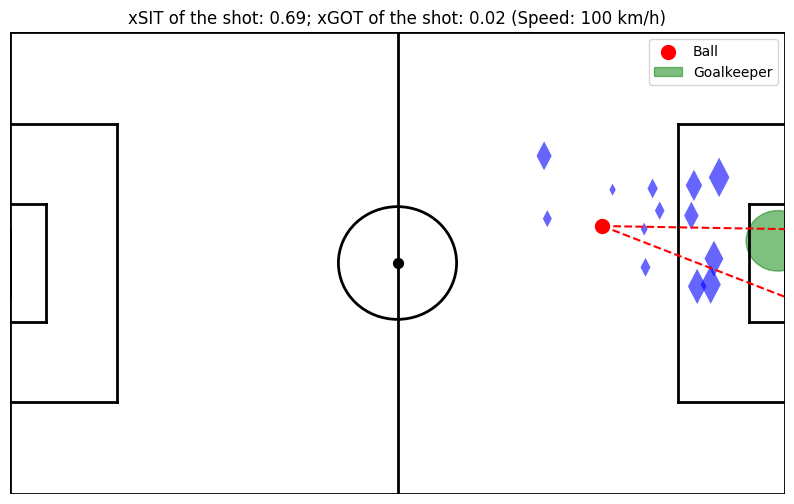

In [56]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon, Circle
from matplotlib.path import Path
import math

def calcular_tiempo_llegada(pos_balon, velocidad_balon, pos_jugador):
    """Calcula el tiempo que tarda el balón en llegar a la posición del jugador"""
    distancia = math.sqrt((pos_balon[0] - pos_jugador[0])**2 + (pos_balon[1] - pos_jugador[1])**2)
    tiempo = distancia / (velocidad_balon * 1000/3600)  # Convertir km/h a m/s
    return tiempo

def calcular_radio_efectivo(tiempo_llegada, radio_base=1.5, tiempo_reaccion=0.4):
    """Ajusta el radio en función del tiempo de llegada vs tiempo de reacción"""
    factor = tiempo_llegada / tiempo_reaccion
    return radio_base * factor

def xss_value(pos_balon, portero, jugadores, velocidad_balon):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 75)
    ax.set_xticks([])  
    ax.set_yticks([])  
    ax.set_frame_on(False)
    ax.set_facecolor('white')

    # Portería
    porteria = [(120, 32), (120, 43)] if pos_balon[0] >= 60 else [(0, 32), (0, 43)]
    
    # Triángulo
    vertices_triangulo = np.array([pos_balon, porteria[0], porteria[1]])
    triangulo = Polygon(vertices_triangulo, closed=True, edgecolor='red', facecolor=(1, 0, 0), linewidth=2)
    ax.add_patch(triangulo)

    # Balón
    ax.scatter(*pos_balon, color='red', s=100, label="Ball")

    # Jugadores con radios dinámicos
    for jugador in jugadores:
        tiempo = calcular_tiempo_llegada(pos_balon, velocidad_balon, jugador)
        radio = calcular_radio_efectivo(tiempo, radio_base=1.5)
        plot_filled_rhombus(jugador[0], jugador[1],radio)

    # Portero con radio dinámico
    tiempo_portero = calcular_tiempo_llegada(pos_balon, velocidad_balon, portero)
    radio_portero = calcular_radio_efectivo(tiempo_portero, radio_base=2.0)
    por = Circle(portero, radius=radio_portero, color='green', alpha=0.5, label="Goalkeeper")
    ax.add_patch(por)

    plt.legend()

    # Procesamiento de la imagen para calcular el área blanca
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape((h, w, 3))
    plt.close(fig)

    transform = ax.transData
    pix_vertices = transform.transform(vertices_triangulo)
    pix_vertices[:, 1] = h - pix_vertices[:, 1]

    path = Path(pix_vertices)
    Y, X = np.mgrid[0:h, 0:w]
    coords = np.vstack((X.ravel(), Y.ravel())).T
    mask = path.contains_points(coords).reshape((h, w))

    colores_dentro = image[mask]
    colores_redondeados = (colores_dentro // 10) * 10
    colores_unicos, counts = np.unique(colores_redondeados, axis=0, return_counts=True)

    for color, count in zip(colores_unicos, counts):
        if tuple(color) == (250, 0, 0):
            porcentaje = count / np.sum(counts)
            return porcentaje

def dibujar_campo_futbol(pos_balon, portero, jugadores, velocidad_balon=80):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Dibujar el campo (igual que antes)
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 75)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    
    # Límites del campo
    ax.plot([0, 120, 120, 0, 0], [0, 0, 75, 75, 0], color="black", linewidth=2)
    
    # Porterías
    porteria_izq = [(0, 32), (0, 43)]
    porteria_der = [(120, 32), (120, 43)]
    ax.plot([0, 0], [32, 43], color="black", linewidth=2)
    ax.plot([120, 120], [32, 43], color="black", linewidth=2)
    
    # Áreas (igual que antes)
    # Dibujar las porterías
    porteria_izq = [(0, 32), (0, 43)]
    porteria_der = [(120, 32), (120, 43)]
    ax.plot([0, 0], [32, 43], color="black", linewidth=2)
    ax.plot([120, 120], [32, 43], color="black", linewidth=2)
    
    # Dibujar el área de penalti
    ax.plot([0, 16.5], [15, 15], color="black", linewidth=2)
    ax.plot([0, 16.5], [60, 60], color="black", linewidth=2)
    ax.plot([16.5, 16.5], [15, 60], color="black", linewidth=2)
    
    ax.plot([120, 103.5], [15, 15], color="black", linewidth=2)
    ax.plot([120, 103.5], [60, 60], color="black", linewidth=2)
    ax.plot([103.5, 103.5], [15, 60], color="black", linewidth=2)
    
    # Dibujar el área pequeña
    ax.plot([0, 5.5], [28, 28], color="black", linewidth=2)
    ax.plot([0, 5.5], [47, 47], color="black", linewidth=2)
    ax.plot([5.5, 5.5], [28, 47], color="black", linewidth=2)
    
    ax.plot([120, 114.5], [28, 28], color="black", linewidth=2)
    ax.plot([120, 114.5], [47, 47], color="black", linewidth=2)
    ax.plot([114.5, 114.5], [28, 47], color="black", linewidth=2)

    # Dibujar el círculo central
    circulo_central = plt.Circle((60, 37.5), 9.15, color='black', fill=False, linewidth=2)
    ax.add_patch(circulo_central)
    ax.scatter(60, 37.5, color='black', s=50)  # Punto central
    
    # Dibujar la línea central
    ax.plot([60, 60], [0, 75], color="black", linewidth=2)
    
    # Dibujar el balón
    ax.scatter(*pos_balon, color='red', s=100, label="Ball")
    
    # Determinar portería más cercana
    if pos_balon[0] < 60:
        porteria = porteria_izq
    else:
        porteria = porteria_der
    
    # Líneas al balón
    for esquina in porteria:
        ax.plot([pos_balon[0], esquina[0]], [pos_balon[1], esquina[1]], color='red', linestyle='dashed')
    
    # Jugadores con radios dinámicos
    for jugador in jugadores:
        tiempo = calcular_tiempo_llegada(pos_balon, velocidad_balon, jugador)
        radio = calcular_radio_efectivo(tiempo, radio_base=1.5)
        plot_filled_rhombus(jugador[0], jugador[1],radio)
    
    # Portero con radio dinámico
    tiempo_portero = calcular_tiempo_llegada(pos_balon, velocidad_balon, portero)
    radio_portero = calcular_radio_efectivo(tiempo_portero, radio_base=2.0)
    por = Circle(portero, radius=radio_portero, color='green', alpha=0.5, label="Goalkeeper")
    ax.add_patch(por)
    
    # Calcular y mostrar xSIT
    porcentaje = xss_value(pos_balon, portero, jugadores, velocidad_balon)
    plt.title(f"xSIT of the shot: {porcentaje:.2f}; xGOT of the shot: 0.02 (Speed: {velocidad_balon} km/h)")
    plt.legend()
    plt.show()

# Ejemplo de uso con velocidad de 80 km/h
pos_balon = "[91.7, 43.5]"
pos_balon = ast.literal_eval(pos_balon)
portero = "[118.9, 41.1]"
portero = ast.literal_eval(portero)
jugadores = "[[109.8, 51.4], [98.4, 36.8], [83.2, 44.7], [109.0, 38.2], [108.5, 34.0], [105.5, 45.2], [105.9, 50.1], [98.2, 43.0], [99.5, 49.6], [106.4, 33.7], [100.6, 46.0], [93.3, 49.4], [82.7, 54.9]]"
jugadores = ast.literal_eval(jugadores)
velocidad = 100
dibujar_campo_futbol(pos_balon,portero,jugadores, velocidad)

### Cálculo de xSIT con circunferencias

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon, Circle
from matplotlib.path import Path
import math

def calcular_tiempo_llegada(pos_balon, velocidad_balon, pos_jugador):
    """Calcula el tiempo que tarda el balón en llegar a la posición del jugador"""
    distancia = math.sqrt((pos_balon[0] - pos_jugador[0])**2 + (pos_balon[1] - pos_jugador[1])**2)
    tiempo = distancia / (velocidad_balon * 1000/3600)  # Convertir km/h a m/s
    return tiempo

def calcular_radio_efectivo(tiempo_llegada, radio_base=1.5, tiempo_reaccion=0.4):
    """Ajusta el radio en función del tiempo de llegada vs tiempo de reacción"""
    factor = tiempo_llegada / tiempo_reaccion
    return radio_base * factor

def xss_value(pos_balon, portero, jugadores, velocidad_balon):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 75)
    ax.set_xticks([])  
    ax.set_yticks([])  
    ax.set_frame_on(False)
    ax.set_facecolor('white')

    # Portería
    porteria = [(120, 32), (120, 43)] if pos_balon[0] >= 60 else [(0, 32), (0, 43)]
    
    # Triángulo
    vertices_triangulo = np.array([pos_balon, porteria[0], porteria[1]])
    triangulo = Polygon(vertices_triangulo, closed=True, edgecolor='red', facecolor=(1, 0, 0), linewidth=2)
    ax.add_patch(triangulo)

    # Balón
    ax.scatter(*pos_balon, color='red', s=100, label="Ball")

    # Jugadores con radios dinámicos
    for jugador in jugadores:
        tiempo = calcular_tiempo_llegada(pos_balon, velocidad_balon, jugador)
        radio = calcular_radio_efectivo(tiempo, radio_base=1.5)
        circulo = Circle(jugador, radius=radio, color='blue', alpha=0.5)
        ax.add_patch(circulo)

    # Portero con radio dinámico
    tiempo_portero = calcular_tiempo_llegada(pos_balon, velocidad_balon, portero)
    radio_portero = calcular_radio_efectivo(tiempo_portero, radio_base=2.0)
    por = Circle(portero, radius=radio_portero, color='green', alpha=0.5, label="Goalkeeper")
    ax.add_patch(por)

    plt.legend()

    # Procesamiento de la imagen para calcular el área blanca
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape((h, w, 3))
    plt.close(fig)

    transform = ax.transData
    pix_vertices = transform.transform(vertices_triangulo)
    pix_vertices[:, 1] = h - pix_vertices[:, 1]

    path = Path(pix_vertices)
    Y, X = np.mgrid[0:h, 0:w]
    coords = np.vstack((X.ravel(), Y.ravel())).T
    mask = path.contains_points(coords).reshape((h, w))

    colores_dentro = image[mask]
    colores_redondeados = (colores_dentro // 10) * 10
    colores_unicos, counts = np.unique(colores_redondeados, axis=0, return_counts=True)

    for color, count in zip(colores_unicos, counts):
        if tuple(color) == (250, 0, 0):
            porcentaje = count / np.sum(counts)
            return porcentaje

### Cálculo de xSIT para los rombos

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon, Circle
from matplotlib.path import Path
import math

def calcular_tiempo_llegada(pos_balon, velocidad_balon, pos_jugador):
    """Calcula el tiempo que tarda el balón en llegar a la posición del jugador"""
    distancia = math.sqrt((pos_balon[0] - pos_jugador[0])**2 + (pos_balon[1] - pos_jugador[1])**2)
    tiempo = distancia / (velocidad_balon)  # Convertir km/h a m/s
    return tiempo

def calcular_radio_efectivo(tiempo_llegada, radio_base=1.5, tiempo_reaccion=0.4):
    """Ajusta el radio en función del tiempo de llegada vs tiempo de reacción"""
    factor = tiempo_llegada / tiempo_reaccion
    return radio_base * factor

def xss_value(pos_balon, portero, jugadores, velocidad_balon):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 75)
    ax.set_xticks([])  
    ax.set_yticks([])  
    ax.set_frame_on(False)
    ax.set_facecolor('white')

    # Portería
    porteria = [(120, 32), (120, 43)] if pos_balon[0] >= 60 else [(0, 32), (0, 43)]
    
    # Triángulo
    vertices_triangulo = np.array([pos_balon, porteria[0], porteria[1]])
    triangulo = Polygon(vertices_triangulo, closed=True, edgecolor='red', facecolor=(1, 0, 0), linewidth=2)
    ax.add_patch(triangulo)

    # Balón
    ax.scatter(*pos_balon, color='red', s=100, label="Ball")

    # Jugadores con radios dinámicos
    for jugador in jugadores:
        tiempo = calcular_tiempo_llegada(pos_balon, velocidad_balon, jugador)
        radio = calcular_radio_efectivo(tiempo, radio_base=1.5)
        plot_filled_rhombus(jugador[0], jugador[1],radio)

    # Portero con radio dinámico
    tiempo_portero = calcular_tiempo_llegada(pos_balon, velocidad_balon, portero)
    radio_portero = calcular_radio_efectivo(tiempo_portero, radio_base=2.0)
    por = Circle(portero, radius=radio_portero, color='green', alpha=0.5, label="Goalkeeper")
    ax.add_patch(por)

    plt.legend()

    # Procesamiento de la imagen para calcular el área blanca
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape((h, w, 3))
    plt.close(fig)

    transform = ax.transData
    pix_vertices = transform.transform(vertices_triangulo)
    pix_vertices[:, 1] = h - pix_vertices[:, 1]

    path = Path(pix_vertices)
    Y, X = np.mgrid[0:h, 0:w]
    coords = np.vstack((X.ravel(), Y.ravel())).T
    mask = path.contains_points(coords).reshape((h, w))

    colores_dentro = image[mask]
    colores_redondeados = (colores_dentro // 10) * 10
    colores_unicos, counts = np.unique(colores_redondeados, axis=0, return_counts=True)

    for color, count in zip(colores_unicos, counts):
        if tuple(color) == (250, 0, 0):
            porcentaje = count / np.sum(counts)
            return porcentaje